In [105]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

In [106]:
def get_stimulus_type(path):

    if "Foils" in path:
        return "foil"

    if path.endswith("a.jpg"):
        return "target"

    if path.endswith("b.jpg"):
        return "lure"

    return "unknown"

In [107]:
def load_test_data(folder_path):

    files = glob.glob(folder_path + "/*test*.csv")

    all_data = []

    for f in files:

        df = pd.read_csv(f)

        # remove rows without image paths
        df = df.dropna(subset=["image_path"])

        df["stim_type"] = df["image_path"].apply(get_stimulus_type)

        participant = os.path.basename(f)[:5]

        df["participant"] = participant

        all_data.append(df)

    data = pd.concat(all_data)

    return data

In [108]:
item_data = load_test_data("MST_Data/item_only/item_only_data")

both_data = load_test_data("MST_Data/Both_item_task/both_data")

task_data = load_test_data("MST_Data/task_only/task_only_data")

In [109]:
item_data["condition"] = "item_only"
both_data["condition"] = "both"
task_data["condition"] = "task_only"

data = pd.concat([item_data, both_data, task_data])

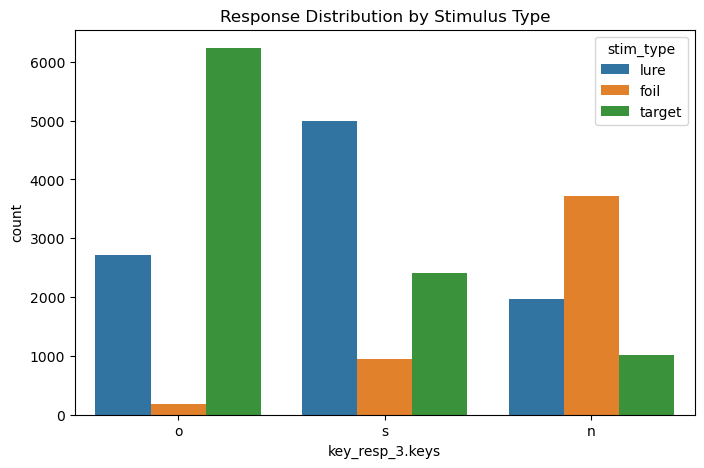

In [110]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="key_resp_3.keys", hue="stim_type")

plt.title("Response Distribution by Stimulus Type")

plt.show()

In [111]:
results = []

for pid in data["participant"].unique():

    sub = data[data["participant"] == pid]

    cond = sub["condition"].iloc[0]

    p_target_old = np.mean(
        (sub["stim_type"] == "target") &
        (sub["key_resp_3.keys"] == "o")
    )

    p_foil_old = np.mean(
        (sub["stim_type"] == "foil") &
        (sub["key_resp_3.keys"] == "o")
    )

    REC = p_target_old - p_foil_old

    p_lure_sim = np.mean(
        (sub["stim_type"] == "lure") &
        (sub["key_resp_3.keys"] == "s")
    )

    p_foil_sim = np.mean(
        (sub["stim_type"] == "foil") &
        (sub["key_resp_3.keys"] == "s")
    )

    LDI = p_lure_sim - p_foil_sim

    results.append([pid, cond, REC, LDI])

results = pd.DataFrame(results, columns=["participant","condition","REC","LDI"])

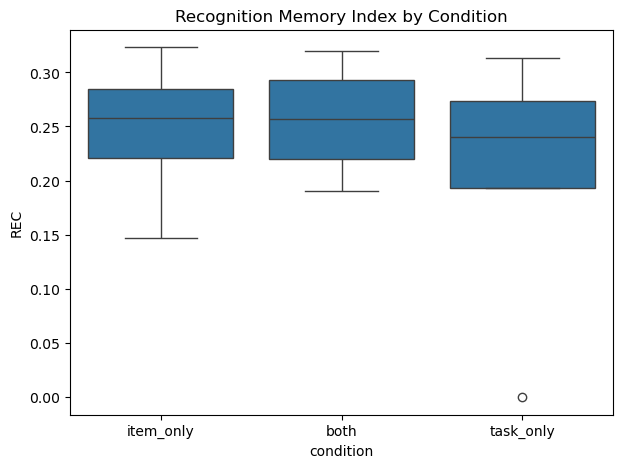

In [112]:
plt.figure(figsize=(7,5))

sns.boxplot(data=results, x="condition", y="REC")

plt.title("Recognition Memory Index by Condition")

plt.show()

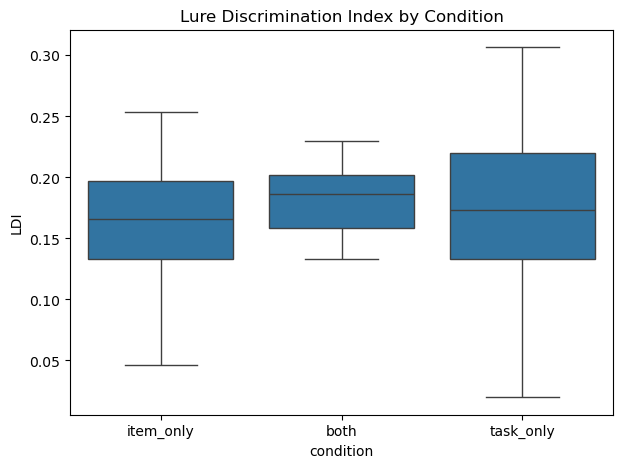

In [113]:
plt.figure(figsize=(7,5))

sns.boxplot(data=results, x="condition", y="LDI")

plt.title("Lure Discrimination Index by Condition")

plt.show()

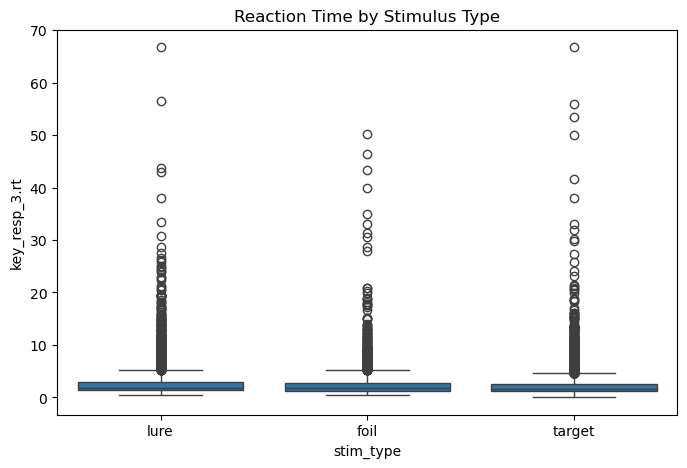

In [114]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x="stim_type", y="key_resp_3.rt")

plt.title("Reaction Time by Stimulus Type")

plt.show()

In [115]:
results.groupby("condition")[["REC","LDI"]].mean()

,REC,LDI
condition,,
both,0.257576,0.183333
item_only,0.253879,0.163413
task_only,0.204000,0.170667


In [116]:
ttest_1samp(results["REC"], 0)

Ttest_1sampResult(statistic=42.10224919580094, pvalue=5.90990375151734e-52)

In [117]:
ttest_1samp(results["LDI"], 0)

Ttest_1sampResult(statistic=30.156784947293126, pvalue=3.273392457012554e-42)

<AxesSubplot:xlabel='REC', ylabel='Count'>

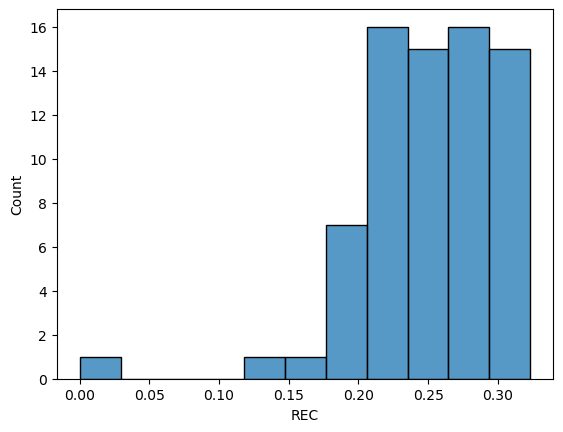

In [118]:
sns.histplot(results["REC"])

<AxesSubplot:xlabel='LDI', ylabel='Count'>

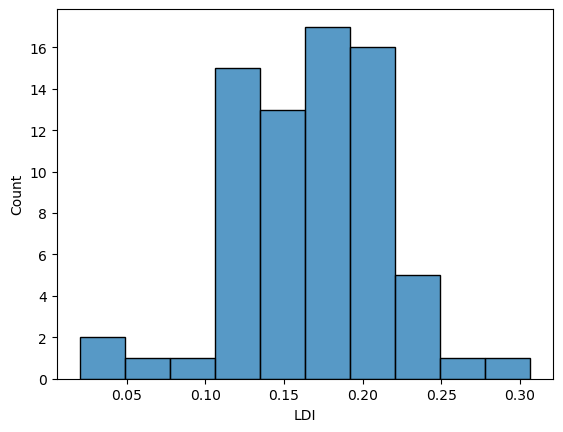

In [119]:
sns.histplot(results["LDI"])

In [120]:
print(data["key_resp_3.keys"].unique())

['o' 's' 'n']


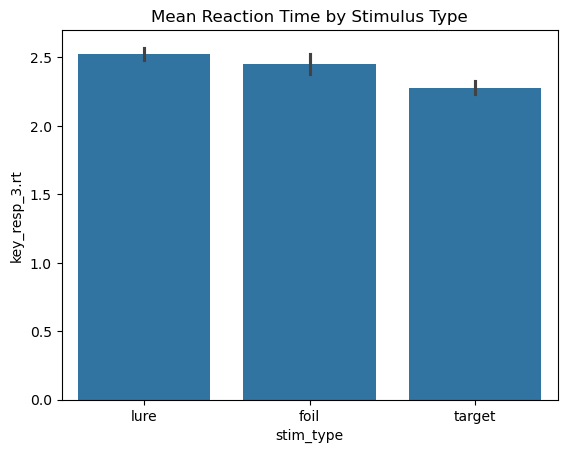

In [121]:
sns.barplot(data=data, x="stim_type", y="key_resp_3.rt")
plt.title("Mean Reaction Time by Stimulus Type")
plt.show()

In [122]:
pd.crosstab(data["stim_type"], data["key_resp_3.keys"], normalize="index")

key_resp_3.keys,n,o,s
stim_type,,,
foil,0.768116,0.037681,0.194203
lure,0.202692,0.280849,0.516460
target,0.104762,0.645445,0.249793


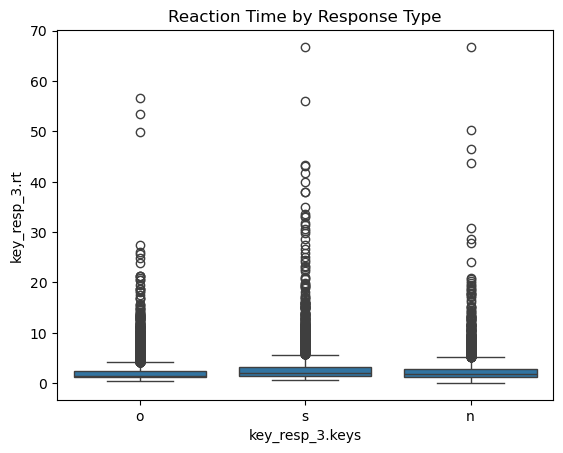

In [123]:
sns.boxplot(data=data, x="key_resp_3.keys", y="key_resp_3.rt")
plt.title("Reaction Time by Response Type")
plt.show()

In [124]:
def load_task_data(folder_path):

    files = glob.glob(folder_path + "/*task*.csv")

    all_data = []

    for f in files:

        df = pd.read_csv(f)

        df = df.dropna(subset=["image_path"])

        participant = os.path.basename(f)[:5]

        df["participant"] = participant

        all_data.append(df)

    return pd.concat(all_data)

In [125]:
item_task = load_task_data("MST_Data/item_only/item_only_data")
both_task = load_task_data("MST_Data/Both_item_task/both_data")
task_task = load_task_data("MST_Data/task_only/task_only_data")

In [126]:
def assign_event_position(df):

    df = df.reset_index(drop=True)

    df["event_pos"] = df.index % 7

    def label_pos(x):
        if x == 0:
            return "pre"
        elif x == 6:
            return "post"
        else:
            return "mid"

    df["event_type"] = df["event_pos"].apply(label_pos)

    return df

In [127]:
item_task = assign_event_position(item_task)
both_task = assign_event_position(both_task)
task_task = assign_event_position(task_task)

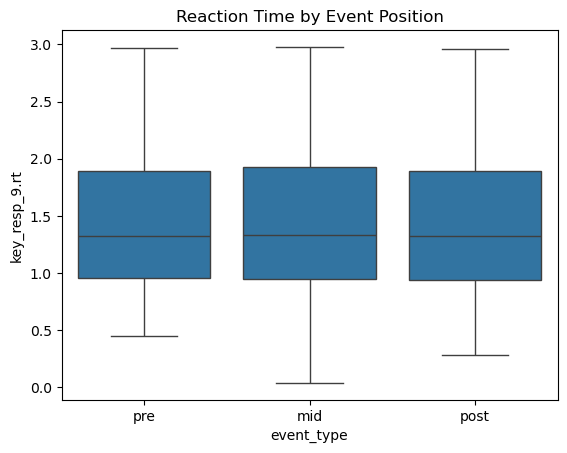

In [128]:
sns.boxplot(data=item_task, x="event_type", y="key_resp_9.rt")

plt.title("Reaction Time by Event Position")

plt.show()

In [129]:
bins = pd.read_csv(
    "MST_Data/item_only/Set6 bins.txt",
    sep="\t",
    header=None,
    names=["stim_id", "bin"]
)
print(bins)

     stim_id  bin
0          1    1
1          2    1
2          3    1
3          4    5
4          5    5
..       ...  ...
187      188    3
188      189    5
189      190    3
190      191    2
191      192    4

[192 rows x 2 columns]


In [136]:
data["image_name"] = data["image_path"].apply(lambda x: str(x).split("/")[-1])
print(data["image_name"])

import re

data["stim_id"] = data["image_name"].apply(
    lambda x: int(re.search(r"\d+", x).group()) if re.search(r"\d+", x) else None
)

6        Objects\130b.jpg
7         Scenes\085b.jpg
8      Foils\scenes11.jpg
9         Scenes\121a.jpg
10       Objects\007b.jpg
              ...        
151      Objects\017b.jpg
152      Objects\299a.jpg
153      Objects\123b.jpg
154      Objects\187a.jpg
155        Foils\066a.jpg
Name: image_name, Length: 24150, dtype: object


In [137]:
print(data[["image_name","stim_id"]].head())

            image_name  stim_id
6     Objects\130b.jpg      130
7      Scenes\085b.jpg       85
8   Foils\scenes11.jpg       11
9      Scenes\121a.jpg      121
10    Objects\007b.jpg        7


In [138]:
print(data.columns)
print(bins.columns)

Index(['thisN', 'thisTrialN', 'thisRepN', 'key_resp_3.keys', 'key_resp_3.rt',
       'key_resp_3.duration', 'trials.thisRepN', 'trials.thisTrialN',
       'trials.thisN', 'thisRow.t',
       ...
       'Unnamed: 88', 'Unnamed: 83', 'condition', 'Unnamed: 84',
       'demo3.started', 'demo3.stopped', 'Unnamed: 82', 'image_name', 'image',
       'stim_id'],
      dtype='object', length=101)
Index(['stim_id', 'bin'], dtype='object')


In [139]:
print(data[["image_path","stim_id"]].head())

            image_path  stim_id
6     Objects\130b.jpg      130
7      Scenes\085b.jpg       85
8   Foils\scenes11.jpg       11
9      Scenes\121a.jpg      121
10    Objects\007b.jpg        7


In [140]:
# # data = data.merge(
# #     bins,
# #     left_on="image_name",
# #     right_on="image",
# #     how="left"
# # )

# # # data = data.concat([data, bins.set_index("image")], axis=1, join="left", ignore_index=False)

# data = data.merge(
#     bins,
#     on="stim_id",
#     how="left"
# )

lure_data = data[data["stim_type"] == "lure"].copy()
print(lure_data["image_path"].head())
print(bins.head())

6     Objects\130b.jpg
7      Scenes\085b.jpg
10    Objects\007b.jpg
13    Objects\018b.jpg
17     Scenes\012b.jpg
Name: image_path, dtype: object
   stim_id  bin
0        1    1
1        2    1
2        3    1
3        4    5
4        5    5


In [146]:
lure_data = data[data["stim_type"] == "lure"]
print(lure_data.head())

    thisN  thisTrialN  thisRepN key_resp_3.keys  key_resp_3.rt  \
6     0.0         0.0       1.0               o       5.110819   
7     1.0         0.0       2.0               o       2.555091   
10    4.0         0.0       5.0               o       3.375687   
13    7.0         0.0       8.0               s       8.987802   
17   11.0         0.0      12.0               s       6.987730   

    key_resp_3.duration  trials.thisRepN  trials.thisTrialN  trials.thisN  \
6                   NaN              1.0                0.0           0.0   
7                   NaN              2.0                0.0           1.0   
10                  NaN              5.0                0.0           4.0   
13                  NaN              8.0                0.0           7.0   
17                  NaN             12.0                0.0          11.0   

     thisRow.t  ...  Unnamed: 88  Unnamed: 83  condition  Unnamed: 84  \
6    90.910565  ...          NaN          NaN  item_only          N

In [147]:

lure_data = lure_data.merge(
    bins,
    on="stim_id",
    how="left"
)
print(lure_data.head())

   thisN  thisTrialN  thisRepN key_resp_3.keys  key_resp_3.rt  \
0    0.0         0.0       1.0               o       5.110819   
1    1.0         0.0       2.0               o       2.555091   
2    4.0         0.0       5.0               o       3.375687   
3    7.0         0.0       8.0               s       8.987802   
4   11.0         0.0      12.0               s       6.987730   

   key_resp_3.duration  trials.thisRepN  trials.thisTrialN  trials.thisN  \
0                  NaN              1.0                0.0           0.0   
1                  NaN              2.0                0.0           1.0   
2                  NaN              5.0                0.0           4.0   
3                  NaN              8.0                0.0           7.0   
4                  NaN             12.0                0.0          11.0   

    thisRow.t  ...  Unnamed: 83  condition  Unnamed: 84  demo3.started  \
0   90.910565  ...          NaN  item_only          NaN            NaN   
1   

In [148]:
lure_bin_perf = lure_data.groupby("bin")["key_resp_3.keys"].apply(
    lambda x: (x == "s").mean()
)

In [149]:
print(lure_bin_perf)

bin
1.0    0.438512
2.0    0.499055
3.0    0.491515
4.0    0.540193
5.0    0.541212
Name: key_resp_3.keys, dtype: float64


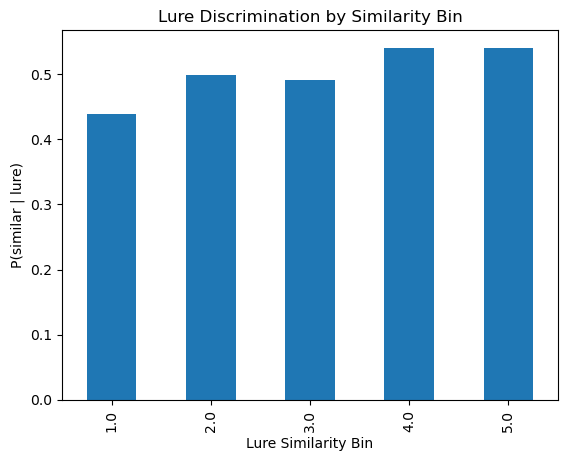

In [150]:
lure_bin_perf.plot(kind="bar")

plt.title("Lure Discrimination by Similarity Bin")
plt.xlabel("Lure Similarity Bin")
plt.ylabel("P(similar | lure)")

plt.show()

Shapiro-Wilk Test for REC: statistic=0.8782, p=0.0000
Shapiro-Wilk Test for LDI: statistic=0.9726, p=0.1176


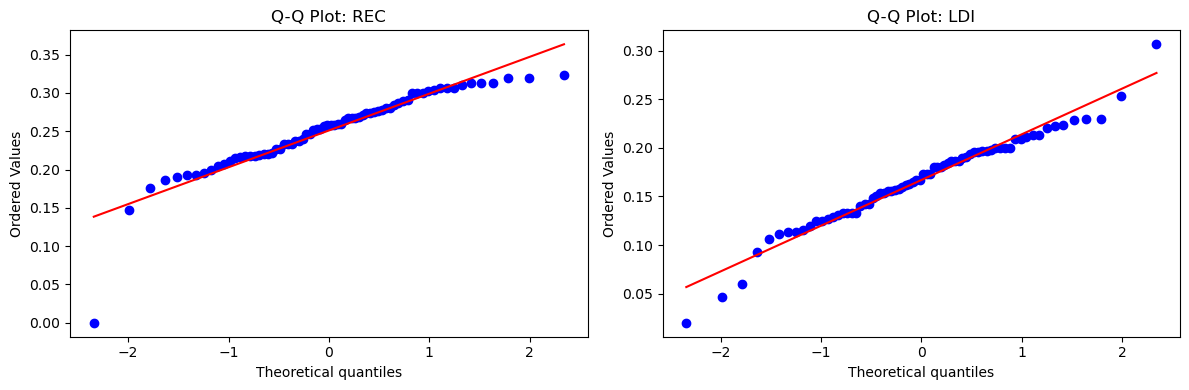


=== One-Sample t-test (vs 0) ===
REC: t = 42.1022, p = 2.9550e-52
LDI: t = 30.1568, p = 1.6367e-42

=== Effect Size (Cohen's d) ===
REC: d = 4.9618
LDI: d = 3.5540
Interpretation: 0.2=small, 0.5=medium, 0.8=large


In [153]:
    from scipy.stats import ttest_1samp, shapiro
    import matplotlib.pyplot as plt
    import seaborn as sns
     
    # --- Normality Check ---
    stat_rec, p_rec = shapiro(results["REC"])
    stat_ldi, p_ldi = shapiro(results["LDI"])
     
    print(f"Shapiro-Wilk Test for REC: statistic={stat_rec:.4f}, p={p_rec:.4f}")
    print(f"Shapiro-Wilk Test for LDI: statistic={stat_ldi:.4f}, p={p_ldi:.4f}")
     
    # Q-Q plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
     
    from scipy.stats import probplot
    probplot(results["REC"], plot=axes[0])
    axes[0].set_title("Q-Q Plot: REC")
     
    probplot(results["LDI"], plot=axes[1])
    axes[1].set_title("Q-Q Plot: LDI")
     
    plt.tight_layout()
    plt.show()
     
    # --- One-sample t-test (if normal) ---
    # H0: REC = 0, H1: REC > 0
    t_rec, p_rec_t = ttest_1samp(results["REC"], 0, alternative="greater")
    t_ldi, p_ldi_t = ttest_1samp(results["LDI"], 0, alternative="greater")
     
    print(f"\n=== One-Sample t-test (vs 0) ===")
    print(f"REC: t = {t_rec:.4f}, p = {p_rec_t:.4e}")
    print(f"LDI: t = {t_ldi:.4f}, p = {p_ldi_t:.4e}")
     
    # --- Effect Size (Cohen's d) ---
    cohen_d_rec = results["REC"].mean() / results["REC"].std()
    cohen_d_ldi = results["LDI"].mean() / results["LDI"].std()
     
    print(f"\n=== Effect Size (Cohen's d) ===")
    print(f"REC: d = {cohen_d_rec:.4f}")
    print(f"LDI: d = {cohen_d_ldi:.4f}")
    print("Interpretation: 0.2=small, 0.5=medium, 0.8=large")
     
    

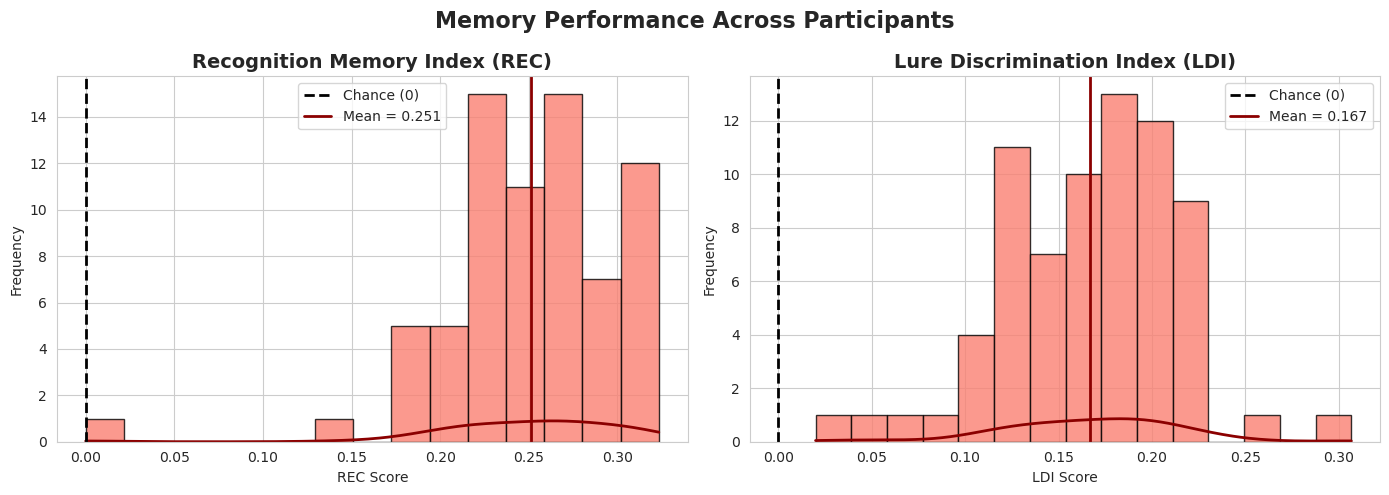

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

rec_vals = np.array(results["REC"])
ldi_vals = np.array(results["LDI"])

fig, axes = plt.subplots(1,2,figsize=(14,5))

# -------- REC --------
axes[0].hist(rec_vals, bins=15, alpha=0.8, edgecolor="black", color="salmon")

# KDE
kde_rec = gaussian_kde(rec_vals)
x_rec = np.linspace(rec_vals.min(), rec_vals.max(), 200)
axes[0].plot(x_rec, kde_rec(x_rec)*len(rec_vals)*(x_rec[1]-x_rec[0]), linewidth=2, color="darkred")

axes[0].axvline(0, linestyle="--", linewidth=2, color="black", label="Chance (0)")
axes[0].axvline(rec_vals.mean(), linestyle="-", linewidth=2, color="darkred",
                label=f"Mean = {rec_vals.mean():.3f}")

axes[0].set_title("Recognition Memory Index (REC)", fontsize=14, weight="bold")
axes[0].set_xlabel("REC Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# -------- LDI --------
axes[1].hist(ldi_vals, bins=15, alpha=0.8, edgecolor="black", color="salmon")

# KDE
kde_ldi = gaussian_kde(ldi_vals)
x_ldi = np.linspace(ldi_vals.min(), ldi_vals.max(), 200)
axes[1].plot(x_ldi, kde_ldi(x_ldi)*len(ldi_vals)*(x_ldi[1]-x_ldi[0]), linewidth=2, color="darkred")

axes[1].axvline(0, linestyle="--", linewidth=2, color="black", label="Chance (0)")
axes[1].axvline(ldi_vals.mean(), linestyle="-", linewidth=2, color="darkred",
                label=f"Mean = {ldi_vals.mean():.3f}")

axes[1].set_title("Lure Discrimination Index (LDI)", fontsize=14, weight="bold")
axes[1].set_xlabel("LDI Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Memory Performance Across Participants", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

In [159]:
!pip install scikit-posthocs

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-posthocs]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Lure data shape after bin merge: (8109, 102)
Bin distribution:
bin
1    1667
2    1587
3    1650
4    1555
5    1650
Name: count, dtype: int64

Per-participant bin performance (first 10 rows):
  participant  bin  p_similar
0       00001    1   0.428571
1       00001    2   0.600000
2       00001    3   0.600000
3       00001    4   0.636364
4       00001    5   0.500000
5       00002    1   0.300000
6       00002    2   0.500000
7       00002    3   0.300000
8       00002    4   0.500000
9       00002    5   0.428571

=== Shapiro-Wilk per Bin ===
Bin 1: W=0.9817, p=0.3781 (normal)
Bin 2: W=0.9435, p=0.0028 (NOT normal)
Bin 3: W=0.9855, p=0.5779 (normal)
Bin 4: W=0.9640, p=0.0373 (NOT normal)
Bin 5: W=0.9771, p=0.2114 (normal)

=== Kruskal-Wallis Test ===
H-statistic = 19.3025, p-value = 6.8535e-04
Eta-squared = 0.0431
Interpretation: 0.01=small, 0.06=medium, 0.14=large

=== Dunn's Post-Hoc Test (Bonferroni corrected) ===
          1         2         3         4         5
1  1.000000  

/tmp/ipykernel_30047/1404121837.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_participant_bin, x="bin", y="p_similar",


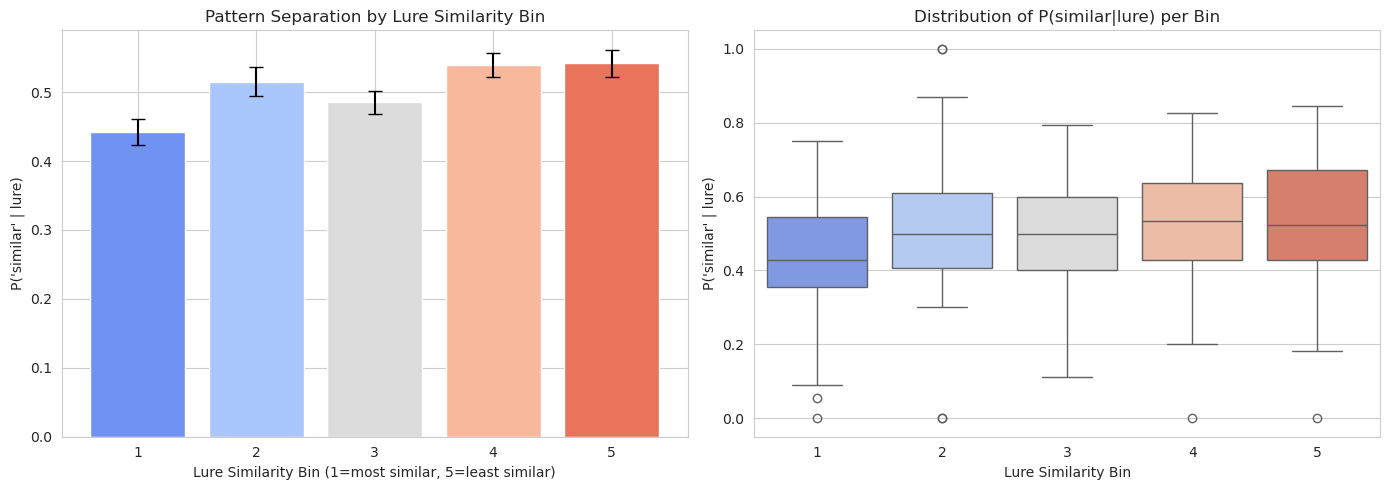

In [160]:
    from scipy.stats import kruskal, mannwhitneyu
    import scikit_posthocs as sp  # pip install scikit-posthocs
     
    # --- Step 1: Compute per-participant P("similar" | lure) for each bin ---
     
    # Make sure lure_data has participant and condition columns
    lure_data = data[data["stim_type"] == "lure"].copy()
     
    # Merge with bins
    lure_data = lure_data.merge(bins, on="stim_id", how="left")
     
    # Drop rows where bin is NaN (scenes lures won't match object bins — expected)
    lure_data = lure_data.dropna(subset=["bin"])
    lure_data["bin"] = lure_data["bin"].astype(int)
     
    print(f"Lure data shape after bin merge: {lure_data.shape}")
    print(f"Bin distribution:\n{lure_data['bin'].value_counts().sort_index()}")
     
    # Per-participant, per-bin: P("similar" | lure)
    per_participant_bin = (
        lure_data.groupby(["participant", "bin"])["key_resp_3.keys"]
        .apply(lambda x: (x == "s").mean())
        .reset_index()
    )
    per_participant_bin.columns = ["participant", "bin", "p_similar"]
     
    print(f"\nPer-participant bin performance (first 10 rows):")
    print(per_participant_bin.head(10))
     
    # --- Step 2: Normality check per bin ---
    print("\n=== Shapiro-Wilk per Bin ===")
    for b in sorted(per_participant_bin["bin"].unique()):
        vals = per_participant_bin[per_participant_bin["bin"] == b]["p_similar"]
        stat, p = shapiro(vals)
        print(f"Bin {b}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(NOT normal)'}")
     
    # --- Step 3: Kruskal-Wallis across all 5 bins ---
    groups = [
        per_participant_bin[per_participant_bin["bin"] == b]["p_similar"].values
        for b in sorted(per_participant_bin["bin"].unique())
    ]
     
    h_stat, p_kruskal = kruskal(*groups)
    print(f"\n=== Kruskal-Wallis Test ===")
    print(f"H-statistic = {h_stat:.4f}, p-value = {p_kruskal:.4e}")
     
    # Effect size: eta-squared
    n_total = sum(len(g) for g in groups)
    eta_sq = (h_stat - len(groups) + 1) / (n_total - len(groups))
    print(f"Eta-squared = {eta_sq:.4f}")
    print("Interpretation: 0.01=small, 0.06=medium, 0.14=large")
     
    # --- Step 4: Post-hoc Dunn's test ---
    print("\n=== Dunn's Post-Hoc Test (Bonferroni corrected) ===")
    dunn = sp.posthoc_dunn(
        per_participant_bin,
        val_col="p_similar",
        group_col="bin",
        p_adjust="bonferroni"
    )
    print(dunn)
     
    # --- Step 5: Focused test — bin 1 vs bin 5 (Mann-Whitney) ---
    bin1 = per_participant_bin[per_participant_bin["bin"] == 1]["p_similar"]
    bin5 = per_participant_bin[per_participant_bin["bin"] == 5]["p_similar"]
     
    u_stat, p_mw = mannwhitneyu(bin1, bin5, alternative="less")  # bin1 < bin5
    r_rb = 1 - (2 * u_stat) / (len(bin1) * len(bin5))  # rank-biserial correlation
     
    print(f"\n=== Mann-Whitney U: Bin 1 vs Bin 5 ===")
    print(f"U-statistic = {u_stat:.4f}, p-value = {p_mw:.4e}")
    print(f"Rank-biserial correlation = {r_rb:.4f}")
    print("Interpretation: 0.1=small, 0.3=medium, 0.5=large")
     
    # --- Step 6: Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
     
    # Mean P(similar|lure) per bin with error bars
    bin_summary = per_participant_bin.groupby("bin")["p_similar"].agg(["mean", "sem"]).reset_index()
    axes[0].bar(bin_summary["bin"], bin_summary["mean"],
                yerr=bin_summary["sem"], capsize=5,
                color=sns.color_palette("coolwarm", 5))
    axes[0].set_xlabel("Lure Similarity Bin (1=most similar, 5=least similar)")
    axes[0].set_ylabel("P('similar' | lure)")
    axes[0].set_title("Pattern Separation by Lure Similarity Bin")
    axes[0].set_xticks([1, 2, 3, 4, 5])
     
    # Boxplot per bin
    sns.boxplot(data=per_participant_bin, x="bin", y="p_similar",
                palette="coolwarm", ax=axes[1])
    axes[1].set_xlabel("Lure Similarity Bin")
    axes[1].set_ylabel("P('similar' | lure)")
    axes[1].set_title("Distribution of P(similar|lure) per Bin")
     
    plt.tight_layout()
    plt.show()